In [7]:
from functions import *
import matplotlib.pyplot as plt
def get_QLF(z, bin_num, dM, obscured, Mmid = 10.3, smhm_scat = .3, prob_zero = [0,0,0], standev = [.85, .85, .35]):

    qlf = QLF(z, bin_num)
    qlf.get_dNdMstar(smhm_scat)
    qlf.get_SMBM(dM, Mmid)
    qlf.get_dNdMbh()
    qlf.get_dNdL(prob_zero, standev, obscured)
    
    return qlf.LumBins, qlf.dNdL


In [5]:
%prun get_QLF(2,100,.6,.7, Mmid=10.7,standev = [.85,.85,.3])


         4593 function calls (4588 primitive calls) in 0.046 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      101    0.007    0.000    0.007    0.000 functions.py:95(get_Mstar)
        3    0.004    0.001    0.004    0.001 fromnumeric.py:2847(ndim)
        5    0.003    0.001    0.023    0.005 shape_base.py:270(apply_along_axis)
      100    0.002    0.000    0.002    0.000 functions.py:131(gauss_array)
      100    0.002    0.000    0.004    0.000 functions.py:189(get_mean_etas)
       10    0.002    0.000    0.002    0.000 fromnumeric.py:592(transpose)
        1    0.002    0.002    0.002    0.002 necompiler.py:765(evaluate)
       10    0.002    0.000    0.002    0.000 {method 'reshape' of 'numpy.ndarray' objects}
        2    0.002    0.001    0.006    0.003 cosmology.py:2140(sigma)
        3    0.001    0.000    0.001    0.000 {built-in method scipy.interpolate._fitpack._spl_}
        2    0.001    0.001    0.001 

Text(0,0.5,'$\\log \\Phi (Mpc^{-3} mag^{-1})$')

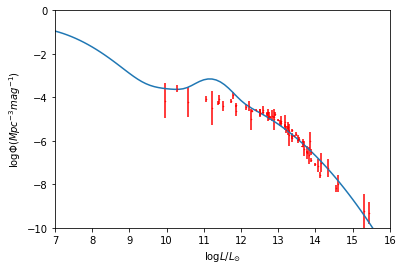

In [88]:
zlist = [0.0, 0.1, 0.2, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0]
z = 2.
xi, yi = get_QLF(z,100,.3,.75, Mmid=10.,standev = [.85,.85,.3])
plt.plot(xi, yi)
x, y , yerr = grab_obs(z)
plt.errorbar(x, y, yerr = yerr, fmt = 'o', markersize = .5,color='r')
plt.axis([7,16,-10,0])
plt.xlabel(r'$\log L/L_{\odot}$')
plt.ylabel(r'$\log \Phi (Mpc^{-3} mag^{-1})$')


MCMC stuff.

In [8]:
import emcee
import corner
import scipy.optimize as op
from functions import *
import matplotlib.pyplot as plt

In [9]:
def model_func(x, p):
    p1, p2 = p
    xm, ym = get_QLF_mcmc(p1, p2)
    y = np.interp(x, xm, ym)
    return y

def lnchi2(p, x, y, err): #lnlike
    
    chi2 = -0.5*np.sum((y-model_func(x,p))**2/(err**2))
    return chi2

def lnprior(p):
    p1, p2 = p
    if 0. < p1 < 3. and 0. < p2 < 1.:
        return 0.0
    return -np.inf

def lnprob(p, x, y, err):
    lp = lnprior(p)
    if np.isfinite(lp):
        return lp + lnchi2(p, x, y, err)
    return -np.inf

z = 3.
bin_num = 200
smhm_scat = .3

qlf = QLF(z, bin_num)
qlf.get_zparams()
qlf.get_dNdMstar(smhm_scat)

### if we go through mcmc for one z value without changing the bin_num of smhm scatter we can do this
def get_QLF_mcmc(dM, obscured, Mmid = 10.3, prob_zero = [0,0,0], standev = [.85, .85, .35]):

    qlf.get_SMBM(dM, Mmid)
    qlf.get_dNdMbh()
    qlf.get_dNdL(prob_zero, standev, obscured)
    
    return qlf.LumBins, qlf.dNdL



In [10]:
xt, yt , yerr = np.array(grab_obs(z))
p = [.5,.5]
ndim, nwalkers = 2, 20

nll = lambda *args: -lnchi2(*args)
result = op.minimize(nll, p, args=(xt, yt, yerr),method = 'Nelder-Mead')

pos = [result["x"] + .1*np.random.randn(ndim) for i in range(nwalkers)]
sampler = emcee.EnsembleSampler(nwalkers, ndim, lnprob, args=(xt,yt,yerr))
sampler.run_mcmc(pos,500)
##more jumps and bigger jumps
##understand results and do a joint fit with all redshifts
##corner plots

print(result)


 final_simplex: (array([[0.47396103, 0.7666021 ],
       [0.47396159, 0.76668088],
       [0.47396269, 0.7665707 ]]), array([55.53897186, 55.53903504, 55.53904082]))
           fun: 55.53897186114615
       message: 'Optimization terminated successfully.'
          nfev: 113
           nit: 59
        status: 0
       success: True
             x: array([0.47396103, 0.7666021 ])


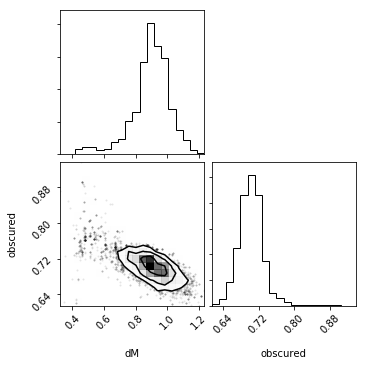

In [11]:
samples = sampler.chain[:,:,:].reshape((-1, ndim))
fig = corner.corner(samples, labels = ['dM','obscured'])
mcmcdM, mcmcObs = np.mean(samples[:,0]), np.mean(samples[:,1])


Text(0,0.5,'$\\log \\Phi (Mpc^{-3} mag^{-1})$')

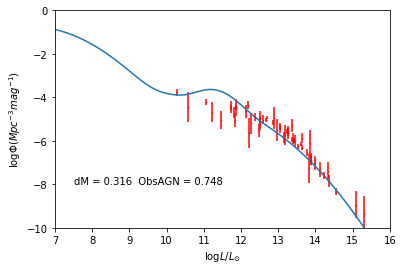

In [23]:
xi, yi = get_QLF_mcmc(mcmcdM, mcmcObs)
plt.plot(xi, yi)
plt.text(7.5,-8,r'dM = '+str(mcmcdM)[:5]+'  ObsAGN = '+str(mcmcObs)[:5])
plt.errorbar(xt, yt, yerr = yerr, fmt = 'o', markersize = .5,color='r')
plt.axis([7,16,-10,0])
plt.xlabel(r'$\log L/L_{\odot}$')
plt.ylabel(r'$\log \Phi (Mpc^{-3} mag^{-1})$')

Stuff I did to fix the interp issue.

13.000000000000007
11.243362186272641 13.000000000000007
12.900000000000007


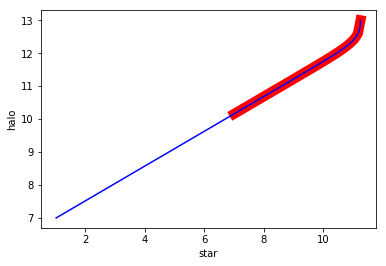

In [13]:
z = 5.
bin_num = 20
Lum = [5,16]
Stell = [7,12]

qlf = QLF(z, bin_num)


max_halo = 15
mhalo = np.linspace(7,max_halo,50)
mstar_h = qlf.get_Mstar(mhalo)

plt.xlabel('star')
plt.ylabel('halo')
stop = np.argmin(sorted(mstar_h) == mstar_h)
while stop != 0:
    max_halo -= .1
    mhalo = np.linspace(7,max_halo,50)
    mstar_h = qlf.get_Mstar(mhalo)
    stop = np.argmin(sorted(mstar_h) == mstar_h)
    
    
max_stell = qlf.get_Mstar(max_halo)
mstar = np.linspace(7,max_stell,50)
mhalo_s = np.interp(mstar, mstar_h, mhalo)
    
plt.plot(mstar, mhalo_s, c='r',linewidth=10)
plt.plot(mstar_h, mhalo, c = 'b')
print(max_stell, max_halo)

slopes = qlf.get_slope(mhalo)
while slopes[-1] < 0:
    max_halo -= .1
    mhalo = np.linspace(7,max_halo,50)
    slopes = qlf.get_slope(mhalo)
print(max_halo)

doing MCMC for lots of redshift.

In [66]:
zlist = [0.0, 0.1, 0.2, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0]
bin_num = 80
smhm_scat = .3

def get_QLF_mcmc(dM, i, obscured = 0.75, Mmid = 10.3, prob_zero = [0,0,0], standev = [.85, .85, .35]):
    
    i.get_SMBM(dM, Mmid)
    i.get_dNdMbh()
    i.get_dNdL(prob_zero, standev, obscured)
    
    return i.LumBins, i.dNdL

def model_func(x, p, i):
    xm, ym = get_QLF_mcmc(p, i)
    y = np.interp(x, xm, ym)
    return y

def lnchi2(p, i, x, y, err): #lnlike
    
    chi2 = -0.5 * np.sum((y - model_func(x, p, i)) ** 2 / (err ** 2))
    return chi2

def lnprior(p):
    if 0.0 < p < 3.0:
        return 0.0
    return -np.inf

def lnprob(p, i, x, y, err):
    lp = lnprior(p)
    if np.isfinite(lp):
        return lp + lnchi2(p, i, x, y, err)
    return -np.inf

qlf_00 = QLF(0.0, bin_num)
qlf_01 = QLF(0.1, bin_num)
qlf_02 = QLF(0.2, bin_num)
qlf_05 = QLF(0.5, bin_num)    
qlf_10 = QLF(1.0, bin_num)
qlf_15 = QLF(1.5, bin_num)
qlf_20 = QLF(2.0, bin_num)
qlf_25 = QLF(2.5, bin_num)
qlf_30 = QLF(3.0, bin_num)
qlf_35 = QLF(3.5, bin_num)
qlf_40 = QLF(4.0, bin_num)
qlf_45 = QLF(4.5, bin_num)
qlf_50 = QLF(5.0, bin_num)
qlf_55 = QLF(5.5, bin_num)
qlf_60 = QLF(6.0, bin_num)

qlf_list = [qlf_00, qlf_01, qlf_02, qlf_05, qlf_10, qlf_15, qlf_20, qlf_25, qlf_30, qlf_35, qlf_40, qlf_45, qlf_50, qlf_55, qlf_60]

for i in qlf_list:
    i.get_zparams()
    i.get_dNdMstar(smhm_scat)

xt_tot = []
yt_tot = []
yerr_tot = []
z_tot = []
for z in zlist:
    x, y, yerr = grab_obs(z)
    xt_tot.extend(x)
    yt_tot.extend(y)
    yerr_tot.extend(yerr)
    for j in range(len(x)):
        z_tot.append(z)

ndim, nwalkers = 1, 20
p = .5
nll = lambda *args: -lnchi2(*args)
results = []
for i, z in zip(qlf_list, zlist):
    xt, yt, yerr = np.array(grab_obs(z))
    results.append(op.minimize(nll, p, args=(i, xt, yt, yerr), method = 'Nelder-Mead')["x"])
pos = [np.mean(results) + .1 * np.random.randn(ndim) for n in range(nwalkers)]

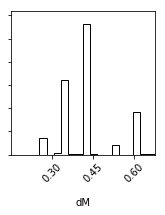

         222266057 function calls (221995562 primitive calls) in 420.900 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
  7213200  110.561    0.000  143.218    0.000 functions.py:190(get_mean_etas)
  7213200   76.371    0.000   76.371    0.000 functions.py:207(gauss)
   270495   49.754    0.000  400.965    0.001 shape_base.py:270(apply_along_axis)
  7213200   39.854    0.000   43.330    0.000 functions.py:181(etas)
  7213200   21.047    0.000   97.418    0.000 functions.py:215(prob_eddratios)
 29852728   19.173    0.000   19.173    0.000 {built-in method numpy.array}
 14426400   14.619    0.000   14.619    0.000 {method 'argmin' of 'numpy.ndarray' objects}
 21910095   13.290    0.000   31.874    0.000 shape_base.py:373(<genexpr>)
 21910095   12.615    0.000   18.584    0.000 index_tricks.py:653(__next__)
 14426400    8.673    0.000   32.658    0.000 fromnumeric.py:1110(argmin)
    90165    7.567    0.000  412.471    0.005 

In [82]:
def lnchi2(p, z, x, y, err): #lnlike
    
    chi2 = -0.5 * np.sum((y - model_func(x, p, z)) ** 2 / (err ** 2))
    return chi2

def model_func(x, p, z, obscured = 0.75, Mmid = 10.3, prob_zero = [0,0,0], standev = [.85, .85, .35]):
    y = []
    
    z = np.array(z)
    for zs, i in zip(zlist, qlf_list):
        i.get_SMBM(p, Mmid)
        i.get_dNdMbh()
        i.get_dNdL(prob_zero, standev, obscured)
        xm, ym = i.LumBins, i.dNdL
        where = (z == zs)  
        y.extend(np.interp(np.array(x)[where], xm, ym))
    return y

sampler = emcee.EnsembleSampler(nwalkers, ndim, lnprob, args=(np.array(z_tot), np.array(xt_tot), np.array(yt_tot), np.array(yerr_tot)))
%prun sampler.run_mcmc(pos,300)


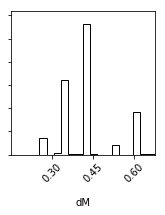

In [83]:
samples = sampler.chain[:,:,:].reshape((-1, ndim))
fig = corner.corner(samples, labels = ['dM'])
mcmcdM = np.mean(samples[:,0])

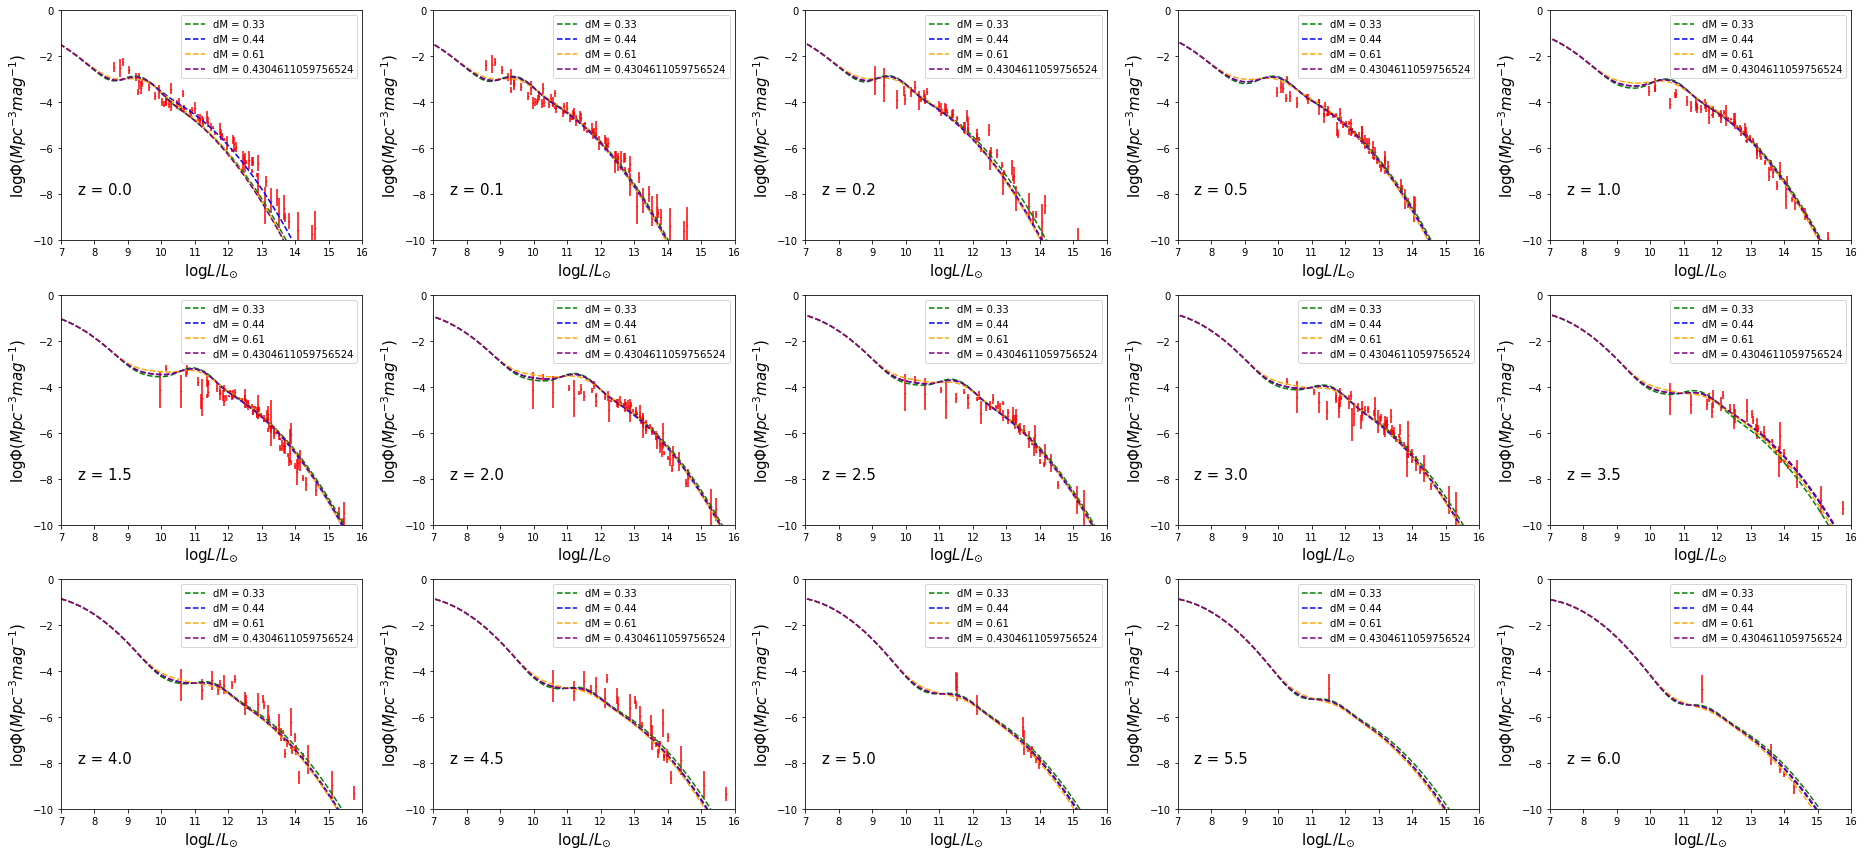

In [86]:
# import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(26,12))
gs = gridspec.GridSpec(3, 5)
fs = 15
mcmc_dM_l = [0.33, 0.44, 0.61, mcmcdM]
for z, i, j in zip(zlist,[0,0,0,0,0,1,1,1,1,1,2,2,2,2,2],[0,1,2,3,4,0,1,2,3,4,0,1,2,3,4]):

    xt, yt , yerr = np.array(grab_obs(z))   
    ax = fig.add_subplot(gs[i, j])
    for dM,c in zip(mcmc_dM_l,['g','b','orange','purple']):
        xm, ym = get_QLF(z, bin_num, dM = dM, obscured = .75, Mmid = 10.3, smhm_scat = .3, prob_zero = [0,0,0], standev = [.85, .85, .35])
        ax.plot(xm,ym,label='dM = '+str(dM),linestyle='dashed',color=c)
    ax.set_xlabel(r'$\log L/L_{\odot}$',fontsize=fs)
    ax.set_ylabel(r'$\log \Phi (Mpc^{-3} mag^{-1})$',fontsize=fs)
    ax.text(7.5,-8,'z = '+str(z),fontsize=fs)
    ax.errorbar(xt, yt, yerr = yerr, fmt = 'o', markersize = .5,color='r')
    ax.axis([7,16,-10,0])
    ax.legend()
        
plt.tight_layout()
plt.savefig('MCMC_dM_QLF_v1.0.pdf')
